In [2]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path
import ants
import pydicom
import nibabel as nib
import os
from glob import glob
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import nilearn

In [3]:
paired_df = pd.read_csv("model_data/adni/paired_df_full.csv", index_col=0)

In [6]:
cort = nilearn.datasets.fetch_atlas_harvard_oxford(
    'cort-maxprob-thr25-2mm'
)

sub = nilearn.datasets.fetch_atlas_harvard_oxford(
    'sub-maxprob-thr25-2mm'
)

[fetch_atlas_harvard_oxford] Dataset found in /Users/william.wakefield/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /Users/william.wakefield/nilearn_data/fsl


In [7]:
cort_img = cort.maps
sub_img = sub.maps

cort_data = cort_img.get_fdata()
sub_data = sub_img.get_fdata()

# shift subcortical labels so they are unique
sub_data[sub_data > 0] += cort_data.max()

combined = cort_data + sub_data

combined_img = nib.Nifti1Image(
    combined,
    cort_img.affine
)

nib.save(combined_img, filename="model_data/HO_cort_sub_combined.nii")

In [8]:
labels = cort.labels + sub.labels[1:]  # remove duplicate background

In [9]:
# Paths for registered images
DTI_REG_DIR = Path("model_data/adni/dti_registered")
T1_REG_DIR = Path("model_data/adni/t1_registered")
ATLAS_PATH = "model_data/HO_cort_sub_combined.nii"

# Get unique ROI labels from atlas (exclude background 0)
atlas_img = nib.load(ATLAS_PATH)
atlas_data = atlas_img.get_fdata()
roi_labels = np.unique(atlas_data).astype(int)
roi_labels = roi_labels[roi_labels > 0]
print(f"Number of ROIs: {len(roi_labels)}")

def extract_voxels_per_roi(img_path, atlas_path, roi_labels):
    """
    Extract voxel values per ROI from a NIfTI image.
    Returns dict: roi_label -> 1D array of voxel values (variable length per ROI).
    """
    img = nib.load(img_path)
    atlas_nii = nib.load(atlas_path)
    atlas_resampled = nilearn.image.resample_to_img(
        atlas_nii, img, interpolation="nearest"
    )
    img_data = img.get_fdata().flatten()
    atlas_flat = atlas_resampled.get_fdata().flatten()
    result = {}
    for label in roi_labels:
        mask = atlas_flat == label
        voxels = img_data[mask]
        if len(voxels) > 0:
            result[label] = voxels.astype(np.float32)
    return result

Number of ROIs: 70


In [10]:
# Load all 212 T1 and DTI images, extract voxels per ROI per modality
t1_voxels_by_roi = {roi: [] for roi in roi_labels}
dti_voxels_by_roi = {roi: [] for roi in roi_labels}

for _, row in tqdm(paired_df.iterrows(), total=len(paired_df), desc="Extracting voxels"):
    t1_path = T1_REG_DIR / row["t1_file_name"]
    dti_path = DTI_REG_DIR / row["dti_file_name"]
    t1_roi_dict = extract_voxels_per_roi(str(t1_path), ATLAS_PATH, roi_labels)
    dti_roi_dict = extract_voxels_per_roi(str(dti_path), ATLAS_PATH, roi_labels)
    for roi in roi_labels:
        t1_voxels_by_roi[roi].append(t1_roi_dict.get(roi, np.array([], dtype=np.float32)))
        dti_voxels_by_roi[roi].append(dti_roi_dict.get(roi, np.array([], dtype=np.float32)))

Extracting voxels: 100%|██████████| 212/212 [00:59<00:00,  3.57it/s]


In [11]:
# Build voxel matrices per ROI: (n_subjects, n_voxels_r) for each modality
N_COMPONENTS = 12
t1_matrices = {}
dti_matrices = {}

for roi in roi_labels:
    t1_arrays = t1_voxels_by_roi[roi]
    dti_arrays = dti_voxels_by_roi[roi]
    # Skip ROIs with no voxels or inconsistent shapes
    t1_arr = np.array(t1_arrays)
    dti_arr = np.array(dti_arrays)
    if t1_arr.ndim >= 2 and dti_arr.ndim >= 2 and t1_arr.shape[1] > 0:
        t1_matrices[roi] = t1_arr
        dti_matrices[roi] = dti_arr

In [12]:
# PCA per ROI for T1 and DTI
t1_embeddings = []
dti_embeddings = []

for roi in t1_matrices:
    t1_mat = t1_matrices[roi]
    dti_mat = dti_matrices[roi]
    n_voxels = t1_mat.shape[1]
    n_comp = min(N_COMPONENTS, n_voxels, t1_mat.shape[0] - 1)
    if n_comp < 1:
        n_comp = 1
    pca_t1 = PCA(n_components=n_comp).fit(t1_mat)
    pca_dti = PCA(n_components=n_comp).fit(dti_mat)
    t1_embeddings.append(pca_t1.transform(t1_mat))
    dti_embeddings.append(pca_dti.transform(dti_mat))

# Concatenate ROI embeddings: (n_subjects, n_rois * n_components) per modality
t1_all = np.hstack(t1_embeddings)
dti_all = np.hstack(dti_embeddings)
X = np.hstack([t1_all, dti_all])
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (212, 1608)


In [13]:
# StandardScaler + Linear SVM with train/test split
from sklearn.pipeline import Pipeline

y = np.array(paired_df["label"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", class_weight="balanced", random_state=42)),
])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

acc = balanced_accuracy_score(y_test, y_pred)
print(f"Balanced accuracy: {acc:.4f}")

Balanced accuracy: 0.8004


In [14]:
# Separate models for T1-only and DTI-only
X_t1_train, X_t1_test, y_t1_train, y_t1_test = train_test_split(
    t1_all, y, test_size=0.2, random_state=42, stratify=y
)
X_dti_train, X_dti_test, y_dti_train, y_dti_test = train_test_split(
    dti_all, y, test_size=0.2, random_state=42, stratify=y
)

pipeline_t1 = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", class_weight="balanced", random_state=42)),
])
pipeline_dti = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", class_weight="balanced", random_state=42)),
])

pipeline_t1.fit(X_t1_train, y_t1_train)
pipeline_dti.fit(X_dti_train, y_dti_train)

acc_t1 = balanced_accuracy_score(y_t1_test, pipeline_t1.predict(X_t1_test))
acc_dti = balanced_accuracy_score(y_dti_test, pipeline_dti.predict(X_dti_test))

print(f"T1-only balanced accuracy: {acc_t1:.4f}")
print(f"DTI-only balanced accuracy: {acc_dti:.4f}")

T1-only balanced accuracy: 0.8586
DTI-only balanced accuracy: 0.7796


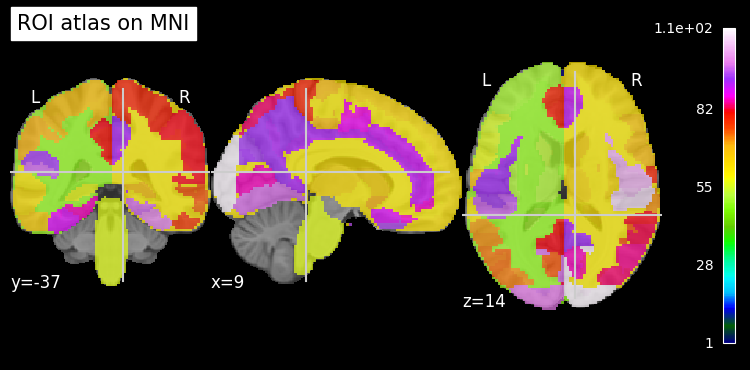

In [47]:
from nilearn.datasets import load_mni152_template

mni = load_mni152_template()
nilearn.plotting.plot_roi(
    "model_data/HO_cort_sub_combined.nii",
    bg_img=mni,
    title="ROI atlas on MNI",
)
nilearn.plotting.show()

In [4]:
amy_data_raw = pd.read_csv('model_data/adni/All_Subjects_UCBERKELEY_AMY_6MM_08Feb2026.csv')

def normalize_subject_id(x):
    s = str(x).strip()
    if s.startswith('ADNI_'):
        s = s.replace('ADNI_', '', 1)
    return s

amy_lookup = pd.DataFrame({
    'subject_id': amy_data_raw['PTID'].astype(str).map(normalize_subject_id),
    'amy_date': pd.to_datetime(amy_data_raw['PROCESSDATE'], errors='coerce'),
    'amyloid_status': amy_data_raw['AMYLOID_STATUS_COMPOSITE_REF']
}).dropna(subset=['subject_id'])

paired_df['dti_date_parsed'] = pd.to_datetime(
    paired_df['dti_date_taken'], format='%Y-%m-%d_%H_%M_%S.%f', errors='coerce'
)
mask = paired_df['dti_date_parsed'].isna()
if mask.any():
    paired_df.loc[mask, 'dti_date_parsed'] = pd.to_datetime(
        paired_df.loc[mask, 'dti_date_taken'], errors='coerce'
    )

paired_df['subject_id_norm'] = paired_df['subject_id'].astype(str).map(normalize_subject_id)

amy_by_subject = {
    sid: grp.dropna(subset=['amy_date']).copy()
    for sid, grp in amy_lookup.groupby('subject_id', sort=False)
}

def nearest_amyloid_status(row):
    sid = row['subject_id_norm']
    dti_dt = row['dti_date_parsed']
    if pd.isna(dti_dt) or sid not in amy_by_subject:
        return np.nan
    subject_rows = amy_by_subject[sid]
    if subject_rows.empty:
        return np.nan
    nearest_idx = (subject_rows['amy_date'] - dti_dt).abs().idxmin()
    return subject_rows.loc[nearest_idx, 'amyloid_status']

paired_df['label_amy'] = paired_df.apply(nearest_amyloid_status, axis=1)

y_amy = pd.to_numeric(paired_df['label_amy'], errors='coerce').values
amy_valid = ~np.isnan(y_amy)
print(f"Subjects with amyloid status: {amy_valid.sum()} / {len(amy_valid)}")

Subjects with amyloid status: 200 / 212


In [15]:
from scipy.stats import spearmanr

models = {
    'Combined (T1+DTI)': (pipeline,      X),
    'T1 only':           (pipeline_t1,   t1_all),
    'DTI only':          (pipeline_dti,  dti_all),
}

print(f"{'Model':<22} {'Spearman rho':>13} {'p-value':>10}")
print("-" * 47)

corr_results = {}
for name, (model, features) in models.items():
    scores = model.decision_function(features[amy_valid])
    rho, p = spearmanr(scores, y_amy[amy_valid])
    corr_results[name] = (rho, p)
    sig = '*' if p < 0.05 else ''
    print(f"{name:<22} {rho:>+13.4f} {p:>10.4f} {sig}")

Model                   Spearman rho    p-value
-----------------------------------------------
Combined (T1+DTI)            +0.1360     0.0548 
T1 only                      +0.1140     0.1080 
DTI only                     +0.1958     0.0055 *


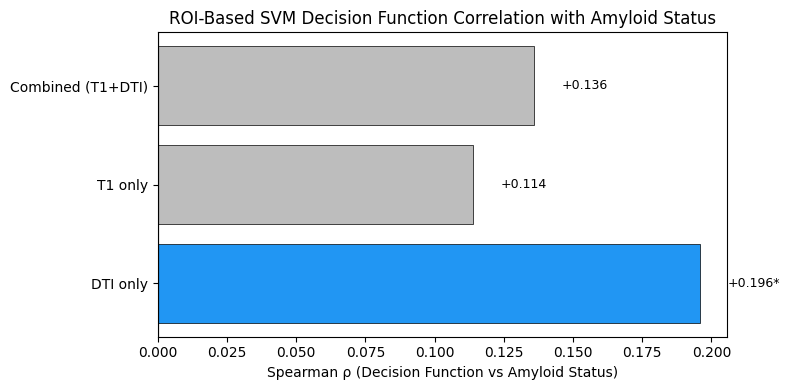

In [16]:
names = list(corr_results.keys())
rhos = [corr_results[n][0] for n in names]
pvals = [corr_results[n][1] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2196F3' if p < 0.05 else '#BDBDBD' for p in pvals]
bars = ax.barh(names, rhos, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Spearman ρ (Decision Function vs Amyloid Status)')
ax.set_title('ROI-Based SVM Decision Function Correlation with Amyloid Status')
ax.axvline(0, color='black', linewidth=0.8)

for bar, rho, p in zip(bars, rhos, pvals):
    label = f'{rho:+.3f}{"*" if p < 0.05 else ""}'
    x_pos = rho + 0.01 if rho >= 0 else rho - 0.01
    ha = 'left' if rho >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2, label,
            va='center', ha=ha, fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.show()